In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator

In [2]:
def bin_singlelc(t,y,yerr, Ninbin):
    ## function to bin a light curve
    counter = 0
    # see how many points we need
    void = []
    while counter < len(t):
        void.append(-99)
        counter += Ninbin
    Nlen = len(void)

    counter = 0
    icounter = 0
    tb = np.zeros(Nlen)
    yb = np.zeros(Nlen)
    yerrb = np.zeros(Nlen)
    while counter < len(t):
        t_inbin = t[counter:counter+Ninbin]
        y_inbin = y[counter:counter+Ninbin]
        yerr_inbin = yerr[counter:counter+Ninbin]

        bin_t = np.nanmedian(t_inbin)
        bin_y = np.nanmedian(y_inbin)
        bin_yerr = np.nanmedian(yerr_inbin) / np.sqrt(Ninbin)

        tb[icounter] = bin_t
        yb[icounter] = bin_y
        yerrb[icounter] = bin_yerr

        counter += Ninbin
        icounter += 1
    return tb, yb, yerrb

In [3]:
## -- load in data from curated npz files
## -- each has light curve data and best-fit models for each case
## -- we'll also bin each light curve for nice plotting

Nbin = 23 # number of points in each bin

## C TRANSIT
## -- case 2
l2 = np.load('./data/lightcurves/broadband_readysave_case2.npz')

t2 = l2['t']
y2 = l2['y']
yerr2 = l2['yerr']
tm2 = l2['tm']
sm2 = l2['sys']
scm2 = l2['scm'] # spot model
fm2 = l2['fm']
dy2 = y2 / sm2
res2 = y2 - fm2
tb2, dyb2, yerrb2 = bin_singlelc(t2, dy2, yerr2, Nbin)
void, resb2, void = bin_singlelc(t2, res2, yerr2, Nbin)
del l2

## -- case 3
l3 = np.load('./data/lightcurves/broadband_readysave_case3.npz')

t3 = l3['t']
y3 = l3['y']
yerr3 = l3['yerr']
tm3 = l3['tm']
sm3 = l3['sys']
fm3 = l3['fm']
dy3 = y3 / sm3
res3 = y3 - fm3
tb3, dyb3, yerrb3 = bin_singlelc(t3, dy3, yerr3, Nbin)
void, resb3, void = bin_singlelc(t3, res3, yerr3, Nbin)
del l3

## B+D TRANSIT
## -- case 2
l2 = np.load('../v1298tau_bd/fits/broadband/v1298tau_bd_broadband_8gaussians_models.npz')

t2bd = l2['t']
y2bd = l2['y']
yerr2bd = l2['yerr']
tm2bd_d = l2['tm_d']
tm2bd_b = l2['tm_b']
sm2bd = l2['sm']
scm2bd = l2['scm'] # spot model
fm2bd = l2['fullmodel']
dy2bd = y2bd / sm2bd
res2bd = y2bd - fm2bd
tb2bd, dyb2bd, yerrb2bd = bin_singlelc(t2bd, dy2bd, yerr2bd, Nbin)
void, resb2bd, void = bin_singlelc(t2bd, res2bd, yerr2bd, Nbin)
del l2

## -- case 3
l3 = np.load('../v1298tau_bd/fits/broadband/v1298tau_bd_broadband_8fleck_models.npz')

t3bd = l3['t']
y3bd = l3['y']
yerr3bd = l3['yerr']
tm3bd_d = l3['tm_d']
tm3bd_b = l3['tm_b']
sm3bd = l3['sm']
fm3bd = l3['fullmodel']
dy3bd = y3bd / sm3bd
res3bd = y3bd - fm3bd
tb3bd, dyb3bd, yerrb3bd = bin_singlelc(t3bd, dy3bd, yerr3bd, Nbin)
void, resb3bd, void = bin_singlelc(t3bd, res3bd, yerr3bd, Nbin)
del l3

In [4]:
## -- colors to use in plot:
c2 = 'green'
c3 = '#6DADE2'

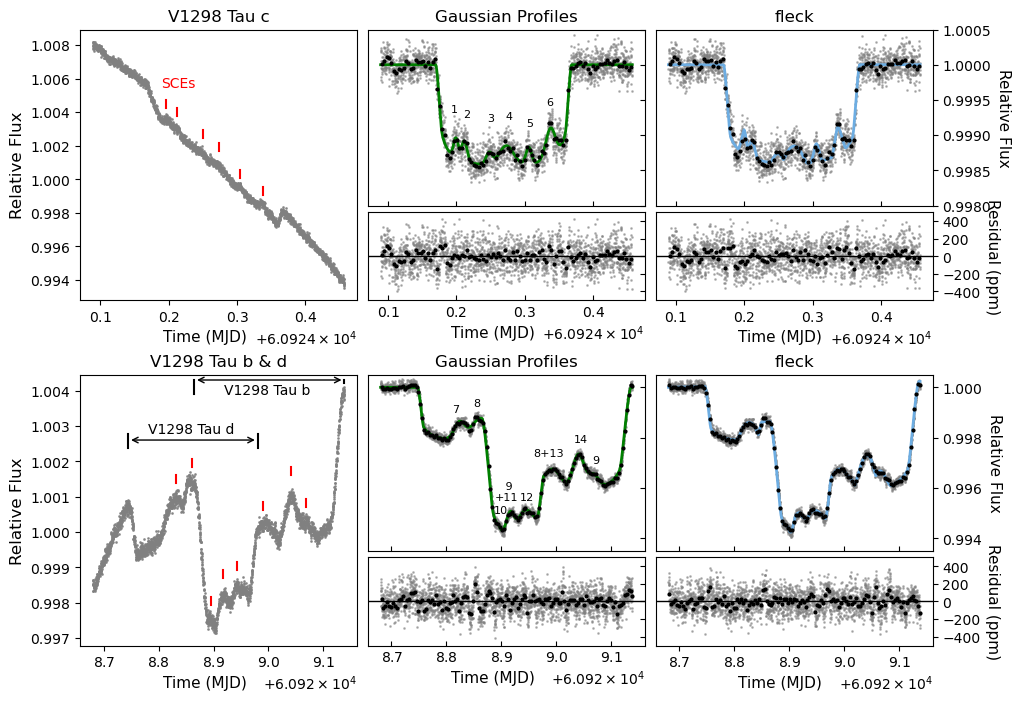

In [5]:
## figure 1:
fig = plt.figure(figsize=(11, 8))
# Main 2x2 grid
gs = GridSpec(2, 3, figure=fig, wspace=0.04, hspace=0.275)
gs_ul = gs[0,0].subgridspec(1, 1)
gs_um = gs[0,1].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
gs_ur = gs[0,2].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
gs_ll = gs[1,0].subgridspec(1, 1)
gs_lm = gs[1,1].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)
gs_lr = gs[1,2].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.05)

# ---- Top row ----
## -- left panel
ax_ul = fig.add_subplot(gs_ul[0])
ax_ul.set_title('V1298 Tau c', fontsize=12)

ax_ul.plot(t2, y2, ls='None', marker='o', ms=1, c='gray', alpha=0.8, zorder=1, rasterized=True)
ax_ul.set_ylabel('Relative Flux', fontsize=12)
ax_ul.set_xlabel("Time (MJD)", fontsize=11, x=0.45)
ax_ul.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_ul.xaxis.set_major_locator(MultipleLocator(0.1))

## -- middle panel
ax_um_top = fig.add_subplot(gs_um[0])
ax_um_bot = fig.add_subplot(gs_um[1], sharex=ax_um_top)
ax_um_top.tick_params(labelleft=False, labelright=False, labelbottom=False, bottom=True, direction='in')
ax_um_bot.tick_params(labelleft=False, labelright=False, labelbottom=True, bottom=True, direction='in')
ax_um_top.set_title("Gaussian Profiles")
ax_um_top.yaxis.set_label_position("right"); ax_um_top.yaxis.tick_right()
ax_um_bot.yaxis.set_label_position("right"); ax_um_bot.yaxis.tick_right()
ax_um_bot.tick_params(axis='y', which='both', direction='in')

ax_um_top.plot(t2, dy2, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1, rasterized=True, label='Detrended Obs.')
ax_um_top.plot(tb2, dyb2, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True, label='Binned')
ax_um_top.plot(t2, (tm2*scm2), lw=2, c=c2, rasterized=True, label='Best-fit')
ax_um_top.set_ylim(0.9980, 1.0005)

ax_um_bot.plot(t2, res2*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1, rasterized=True)
ax_um_bot.plot(tb2, resb2*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True)
ax_um_bot.axhline(0., c='black', lw=1)
ax_um_bot.yaxis.set_major_locator(MultipleLocator(200))#; ax_ur_bot.yaxis.set_minor_locator(MultipleLocator(100))

ax_um_bot.set_xlabel("Time (MJD)", fontsize=11, x=0.45)
ax_um_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_um_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_um_bot.set_ylim(-500,500)

# ---- Right panel ----
ax_ur_top = fig.add_subplot(gs_ur[0])
ax_ur_bot = fig.add_subplot(gs_ur[1], sharex=ax_ur_top)
ax_ur_top.tick_params(labelbottom=False, bottom=True, direction='in')
ax_ur_top.tick_params(axis='y', which='both', direction='out')
ax_ur_top.set_title("fleck")

ax_ur_top.plot(t3, dy3, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1, rasterized=True)
ax_ur_top.plot(tb3, dyb3, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True)
ax_ur_top.plot(t3, (tm3), lw=2, c=c3, rasterized=True)
ax_ur_top.set_ylim(0.9980, 1.0005)
ax_ur_top.set_ylabel("Relative Flux", fontsize=11, rotation=-90, labelpad=14)
ax_ur_top.yaxis.set_label_position("right"); ax_ur_top.yaxis.tick_right()
ax_ur_bot.yaxis.set_label_position("right"); ax_ur_bot.yaxis.tick_right()

ax_ur_bot.plot(t3, res3*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1, rasterized=True)
ax_ur_bot.plot(tb3, resb3*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True)
ax_ur_bot.axhline(0., c='black', lw=1)
ax_ur_bot.yaxis.set_major_locator(MultipleLocator(200))#; ax_ur_bot.yaxis.set_minor_locator(MultipleLocator(100))
ax_ur_bot.set_ylabel("Residual (ppm)", fontsize=11, rotation=-90, labelpad=14)
ax_ur_bot.set_xlabel("Time (MJD)", fontsize=11, x=0.45)
ax_ur_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_ur_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_ur_bot.set_ylim(-500,500)

ax_um_top.text(0.30, 0.53, '1', c='black', fontsize=8, transform=ax_um_top.transAxes)
ax_um_top.text(0.345, 0.5, '2', c='black', fontsize=8, transform=ax_um_top.transAxes)
ax_um_top.text(0.43, 0.48, '3', c='black', fontsize=8, transform=ax_um_top.transAxes)
ax_um_top.text(0.495, 0.49, '4', c='black', fontsize=8, transform=ax_um_top.transAxes)
ax_um_top.text(0.57, 0.45, '5', c='black', fontsize=8, transform=ax_um_top.transAxes)
ax_um_top.text(0.645, 0.57, '6', c='black', fontsize=8, transform=ax_um_top.transAxes)

# ---- Bottom row ----
## -- left panel
ax_ll = fig.add_subplot(gs_ll[0])
ax_ll.set_title('V1298 Tau b & d', fontsize=12)

ax_ll.plot(t2bd, y2bd, ls='None', marker='o', ms=1, c='gray', alpha=0.8, zorder=1, rasterized=True)
ax_ll.set_ylabel('Relative Flux', fontsize=12)
ax_ll.set_xlabel("Time (MJD)", fontsize=11, x=0.45)
ax_ll.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_ll.xaxis.set_major_locator(MultipleLocator(0.1))

## -- middle panel
ax_lm_top = fig.add_subplot(gs_lm[0])
ax_lm_bot = fig.add_subplot(gs_lm[1], sharex=ax_lm_top)
ax_lm_top.tick_params(labelleft=False, labelright=False, labelbottom=False, bottom=True, direction='in')
ax_lm_bot.tick_params(labelleft=False, labelright=False, labelbottom=True, bottom=True, direction='in')
ax_lm_top.set_title("Gaussian Profiles")
ax_lm_top.yaxis.set_label_position("right"); ax_lm_top.yaxis.tick_right()
ax_lm_bot.yaxis.set_label_position("right"); ax_lm_bot.yaxis.tick_right()
ax_lm_bot.tick_params(axis='y', which='both', direction='in')

ax_lm_top.plot(t2bd, dy2bd, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1, rasterized=True, label='Detrended Obs.')
ax_lm_top.plot(tb2bd, dyb2bd, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True, label='Binned')
ax_lm_top.plot(t2bd, (tm2bd_d*tm2bd_b*scm2bd), lw=2, c=c2, rasterized=True, label='Best-fit')
ax_lm_top.set_ylim(0.9935, 1.0005)

ax_lm_bot.plot(t2bd, res2bd*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1, rasterized=True)
ax_lm_bot.plot(tb2bd, resb2bd*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True)
ax_lm_bot.axhline(0., c='black', lw=1)
ax_lm_bot.yaxis.set_major_locator(MultipleLocator(200))#; ax_ur_bot.yaxis.set_minor_locator(MultipleLocator(100))

ax_lm_bot.set_xlabel("Time (MJD)", fontsize=11, x=0.45)
ax_lm_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_lm_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_lm_bot.set_ylim(-500,500)

# ---- Right panel ----
ax_lr_top = fig.add_subplot(gs_lr[0])
ax_lr_bot = fig.add_subplot(gs_lr[1], sharex=ax_lr_top)
ax_lr_top.tick_params(labelbottom=False, bottom=True, direction='in')
ax_lr_top.tick_params(axis='y', which='both', direction='out')
ax_lr_top.set_title("fleck")

ax_lr_top.plot(t3bd, dy3bd, ls='None', marker='o', ms=1, c='gray', alpha=0.50, zorder=1, rasterized=True)
ax_lr_top.plot(tb3bd, dyb3bd, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True)
ax_lr_top.plot(t3bd, (tm3bd_d*tm3bd_b), lw=2, c=c3, rasterized=True)
ax_lr_top.set_ylim(0.9935, 1.0005)
ax_lr_top.set_ylabel("Relative Flux", fontsize=11, rotation=-90, labelpad=14)
ax_lr_top.yaxis.set_label_position("right"); ax_lr_top.yaxis.tick_right()
ax_lr_bot.yaxis.set_label_position("right"); ax_lr_bot.yaxis.tick_right()

ax_lr_bot.plot(t3bd, res3bd*1.e6, ls='None', marker='o', ms=1, c='gray', alpha=0.5, zorder=1, rasterized=True)
ax_lr_bot.plot(tb3bd, resb3bd*1.e6, ls='None', marker='o', ms=2, c='black', alpha=1, lw=1, zorder=5, rasterized=True)
ax_lr_bot.axhline(0., c='black', lw=1)
ax_lr_bot.yaxis.set_major_locator(MultipleLocator(200))#; ax_ur_bot.yaxis.set_minor_locator(MultipleLocator(100))
ax_lr_bot.set_ylabel("Residual (ppm)", fontsize=11, rotation=-90, labelpad=14)
ax_lr_bot.set_xlabel("Time (MJD)", fontsize=11, x=0.45)
ax_lr_bot.ticklabel_format(axis="x", style="plain", useOffset=True, useMathText=True, scilimits=(-5,10))
ax_lr_bot.xaxis.set_major_locator(MultipleLocator(0.1))
ax_lr_bot.set_ylim(-500,500)

# annotations:
# contact points:
# ax_ul.axvline(t3[520], c='black', ymin=0.65, ymax=0.68), ax_ul.text(t3[520-40], 1.00275, r't$_1$', fontsize=10, c='black')
# ax_ul.axvline(t3[610], c='black', ymin=0.55, ymax=0.58), ax_ul.text(t3[610-40], 1.001, r't$_2$', fontsize=10, c='black')
# ax_ul.axvline(t3[1730], c='black', ymin=0.21, ymax=0.24), ax_ul.text(t3[1730-40], 0.9947, r't$_3$', fontsize=10, c='black')
# ax_ul.axvline(t3[1820], c='black', ymin=0.25, ymax=0.28), ax_ul.text(t3[1820-30], 0.9955, r't$_4$', fontsize=10, c='black')

ax_ll.axvline(t3bd[420], c='black', ymin=0.73, ymax=0.78)
ax_ll.axvline(t3bd[1950], c='black', ymin=0.73, ymax=0.78)
ax_ll.annotate(text='', xytext=(t3bd[420],1.0026), xy=(t3bd[1950], 1.0026), arrowprops=dict(arrowstyle='<->'))
ax_ll.text(t3bd[650], 1.0028, 'V1298 Tau d', fontsize=10, c='black')

ax_ll.axvline(t3bd[1200], c='black', ymin=0.93, ymax=0.98)
ax_ll.axvline(t3bd[-1], c='black', ymin=0.97, ymax=0.98)
ax_ll.annotate(text='', xytext=(t3bd[1200],1.0043), xy=(t3bd[-1], 1.0043), arrowprops=dict(arrowstyle='<->'))
ax_ll.text(t3bd[1550], 1.0039, 'V1298 Tau b', fontsize=10, c='black')

# starspots:
ax_ul.axvline(t3[700], c='red', ymin=0.71, ymax=0.74), ax_ul.text(t3[700-50], 1.0055, 'SCEs', fontsize=10, c='red')
ax_ul.axvline(t3[800], c='red', ymin=0.68, ymax=0.71)
ax_ul.axvline(t3[1050], c='red', ymin=0.60, ymax=0.63)
ax_ul.axvline(t3[1200], c='red', ymin=0.55, ymax=0.58)
ax_ul.axvline(t3[1400],c='red', ymin=0.45, ymax=0.48)
ax_ul.axvline(t3[1620],c='red', ymin=0.39, ymax=0.42)

ax_ll.axvline(t3bd[990], c='red', ymin=0.6, ymax=0.63)
ax_ll.axvline(t3bd[1170], c='red', ymin=0.66, ymax=0.69)
ax_ll.axvline(t3bd[1400], c='red', ymin=0.15, ymax=0.18)
ax_ll.axvline(t3bd[1535], c='red', ymin=0.25, ymax=0.28)
ax_ll.axvline(t3bd[1700], c='red', ymin=0.28, ymax=0.31)
ax_ll.axvline(t3bd[2010], c='red', ymin=0.5, ymax=0.53)
ax_ll.axvline(t3bd[2350], c='red', ymin=0.63, ymax=0.66)
ax_ll.axvline(t3bd[2520], c='red', ymin=0.51, ymax=0.54)

ax_lm_top.text(t3bd[850], 0.999, '7',c='black', fontsize=8)
ax_lm_top.text(t3bd[1100],0.99925, '8', c='black', fontsize=8)
ax_lm_top.text(t3bd[1350],0.9955, '   9\n+11', c='black', fontsize=8)
ax_lm_top.text(t3bd[1335],0.995, '10', c='black', fontsize=8)
ax_lm_top.text(t3bd[1650],0.9955, '12', c='black', fontsize=8)
ax_lm_top.text(t3bd[1800],0.99725, '8+13', c='black', fontsize=8)
ax_lm_top.text(t3bd[2280],0.9978, '14', c='black', fontsize=8)
ax_lm_top.text(t3bd[2500],0.997, '9', c='black', fontsize=8)

plt.savefig('./figures/Figure2_broadbandlightcurves.pdf', format='PDF', dpi=600, bbox_inches='tight')
plt.show()